# Exploratory Data Analysis — Text OSINT AI Dataset

This notebook profiles the cleaned instruction-tuning dataset used to fine-tune `Maximuz23/Text-OSINT` (a LoRA adapter on Llama 3.2 3B).

**Source data:** `data/02_processed/v2_0_cleaned.jsonl` — 114K records after cleaning, deduplication, cross-split deduplication, truncation removal, and generic AI-disclaimer filtering.

**What this notebook covers:**

1. Source distribution across 22 OSINT data providers
2. Real vs AI-generated record split
3. User-message text length distribution
4. IOC coverage (CVE / IP / domain / hash / URL patterns)
5. MITRE ATT&CK technique coverage
6. Kill chain phase coverage
7. Summary stats

Charts are also saved as standalone PNGs under `reports/eda/` for direct linking.


## Setup

Loads dependencies, the cleaned dataset, and the output directory for chart PNGs.


In [1]:
%matplotlib inline
import json, os, re, collections, statistics
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

CLEANED = os.path.expanduser("~/osint-project/data/02_processed/v2_0_cleaned.jsonl")
OUT_DIR = os.path.expanduser("~/osint-project/reports/eda")
os.makedirs(OUT_DIR, exist_ok=True)

records = []
with open(CLEANED) as f:
    for line in f:
        try:
            records.append(json.loads(line))
        except Exception:
            pass

total = len(records)
print(f"Total records loaded: {total:,}")


Total records loaded: 114,403


## 1. Source Distribution

The dataset draws from 22 distinct providers spanning vulnerability databases (NVD, Exploit-DB, GHSA, CISA KEV), threat intel feeds (OTX, ThreatFox, URLhaus), red team knowledge (MITRE ATT&CK, Atomic Red Team), security discourse (Telegram, Hacker News, BleepingComputer), and HuggingFace cybersecurity datasets.

The largest sources are deliberately downsampled (e.g. NVD CVE 118K → ~18K) to prevent any single source from dominating the model's behavior.


Records per source:

  exploitdb                       19199 (16.8%)  ██████
  hf_fenrir                       18943 (16.6%)  ██████
  cve                             18296 (16.0%)  ██████
  otx                              8288 ( 7.2%)  ██
  hf_cti                           7537 ( 6.6%)  ██
  ghsa                             5480 ( 4.8%)  █
  arxiv_security                   5008 ( 4.4%)  █
  hf_hackernews                    4986 ( 4.4%)  █
  threatfox                        4366 ( 3.8%)  █
  misp_galaxy                      3761 ( 3.3%)  █
  telegram                         3331 ( 2.9%)  █
  hf_loghub                        3223 ( 2.8%)  █
  hf_wikipedia_security            2858 ( 2.5%)  
  mitre_attack                     2212 ( 1.9%)  
  hf_cyber_v1                      1889 ( 1.7%)  
  atomic_red_team                  1500 ( 1.3%)  
  cisa_kev                         1396 ( 1.2%)  
  abusech                          1133 ( 1.0%)  
  synthetic_uncertainty             820 ( 0.7%)  


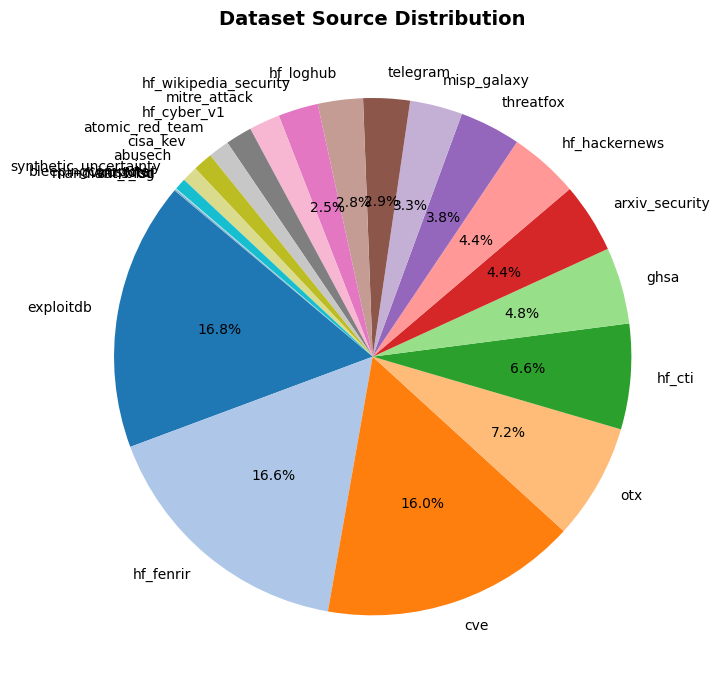

In [2]:
source_counts = collections.Counter(r.get("source", "unknown") for r in records)
print("Records per source:\n")
for src, count in source_counts.most_common():
    bar = "█" * int(count / total * 40)
    pct = count / total * 100
    print(f"  {src:<30} {count:>6} ({pct:4.1f}%)  {bar}")

fig, ax = plt.subplots(figsize=(10, 7))
labels = [s for s, _ in source_counts.most_common()]
sizes  = [c for _, c in source_counts.most_common()]
colors = plt.cm.tab20.colors
ax.pie(sizes, labels=labels, autopct=lambda p: f'{p:.1f}%' if p > 2 else '',
       colors=colors[:len(labels)], startangle=140)
ax.set_title("Dataset Source Distribution", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/source_distribution.png", dpi=150, bbox_inches='tight')
plt.show()


## 2. Real vs AI-Generated

`hf_fenrir` and `hf_cyber_v1` are AI-generated Q&A datasets. Everything else is human-curated (API feeds, NVD descriptions, threat reports, public news, public Telegram channels, etc.).

The AI-generated subset contributes structured Q&A format and breadth of cybersecurity concepts; the human-curated backbone provides real-world authoritative content. Heuristic for the model's behavior: **dominantly real, with AI-generated providing supplementary structure.**


  Real data (human / API feeds) : 93,571 (81.8%)
  AI-generated (synthetic Q&A)  : 20,832  (18.2%)


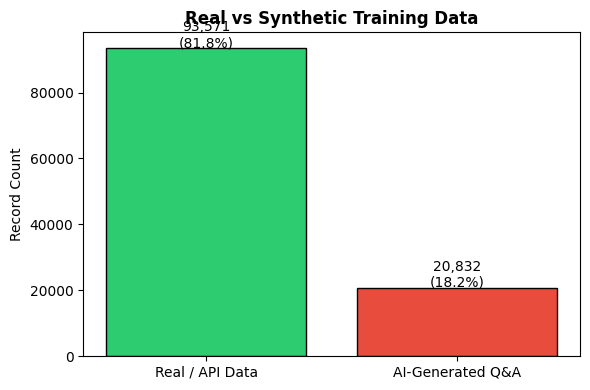

In [3]:
AI_GENERATED = {"hf_fenrir", "hf_cyber_v1"}
real_count = sum(1 for r in records if r.get("source") not in AI_GENERATED)
ai_count   = total - real_count
print(f"  Real data (human / API feeds) : {real_count:,} ({real_count/total*100:.1f}%)")
print(f"  AI-generated (synthetic Q&A)  : {ai_count:,}  ({ai_count/total*100:.1f}%)")

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(["Real / API Data", "AI-Generated Q&A"], [real_count, ai_count],
       color=["#2ecc71", "#e74c3c"], edgecolor='black')
ax.set_ylabel("Record Count")
ax.set_title("Real vs Synthetic Training Data", fontweight='bold')
for i, v in enumerate([real_count, ai_count]):
    ax.text(i, v + 200, f"{v:,}\n({v/total*100:.1f}%)", ha='center', fontsize=10)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/real_vs_synthetic.png", dpi=150)
plt.show()


## 3. Text Length Distribution

User-message length distribution drove the choice of `max_seq_length=1024` for training: the p99 of user-message length is ~1080 tokens (~4× chars per token gives ~270 tokens median). Anything beyond 1024 is truncated by the smart-truncation step (cuts at sentence boundary, not mid-token).

This matters because attention is O(L²), so doubling sequence length quadruples compute. Picking the smallest length that captures the bulk of real records is the right cost/quality trade.


  Min    : 2 chars
  Max    : 4,209 chars
  Mean   : 507 chars
  Median : 315 chars
  Stdev  : 482 chars

  Length bucket breakdown:
  <100           2480 (2.2%)
  100-500       78568 (68.7%)
  500-1000      17715 (15.5%)
  1000-2000     12509 (10.9%)
  2000-4096      3098 (2.7%)
  >4096            33 (0.0%)


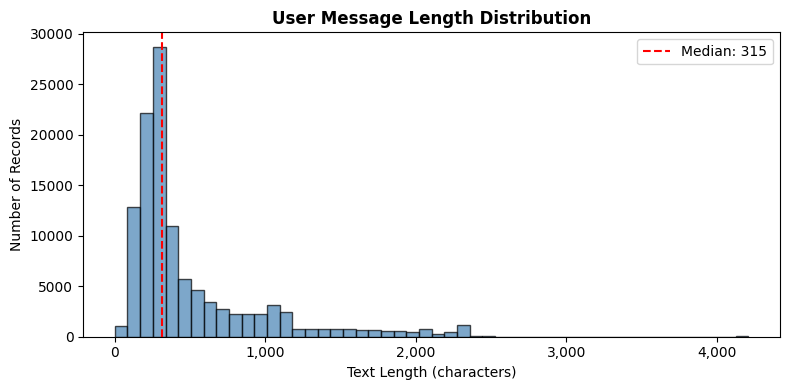

In [4]:
lengths = []
for r in records:
    msgs = r.get("messages", [])
    user_msg = next((m["content"] for m in msgs if m["role"] == "user"), "")
    lengths.append(len(user_msg))

print(f"  Min    : {min(lengths):,} chars")
print(f"  Max    : {max(lengths):,} chars")
print(f"  Mean   : {statistics.mean(lengths):,.0f} chars")
print(f"  Median : {statistics.median(lengths):,.0f} chars")
print(f"  Stdev  : {statistics.stdev(lengths):,.0f} chars")

buckets = {"<100": 0, "100-500": 0, "500-1000": 0, "1000-2000": 0, "2000-4096": 0, ">4096": 0}
for l in lengths:
    if   l < 100:    buckets["<100"] += 1
    elif l < 500:    buckets["100-500"] += 1
    elif l < 1000:   buckets["500-1000"] += 1
    elif l < 2000:   buckets["1000-2000"] += 1
    elif l <= 4096:  buckets["2000-4096"] += 1
    else:            buckets[">4096"] += 1

print("\n  Length bucket breakdown:")
for bucket, count in buckets.items():
    print(f"  {bucket:<12} {count:>6} ({count/total*100:.1f}%)")

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(lengths, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
ax.axvline(statistics.median(lengths), color='red', linestyle='--',
           label=f'Median: {statistics.median(lengths):.0f}')
ax.set_xlabel("Text Length (characters)")
ax.set_ylabel("Number of Records")
ax.set_title("User Message Length Distribution", fontweight='bold')
ax.legend()
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/text_length_distribution.png", dpi=150)
plt.show()


## 4. IOC Coverage

How many records contain each type of Indicator of Compromise? IOCs are matched against the **defanged** representation (`hxxp`, `[.]`) since the cleaning pipeline defangs all URLs/IPs/domains before training to avoid models accidentally producing live-clickable malicious links.

Pattern definitions:
- **CVE:** `CVE-YYYY-NNNN`
- **IP:** defanged dotted quad (`x[.]x[.]x[.]x`)
- **Domain:** defanged `name[.]tld`
- **Hash:** 32–64 hex chars (MD5/SHA1/SHA256)
- **URL:** `hxxp://` / `hxxps://`


  has_CVE          40016 (35.0%)
  has_IP            4416 (3.9%)
  has_domain       15394 (13.5%)
  has_hash          1710 (1.5%)
  has_url          12624 (11.0%)
  no_ioc           59684 (52.2%)


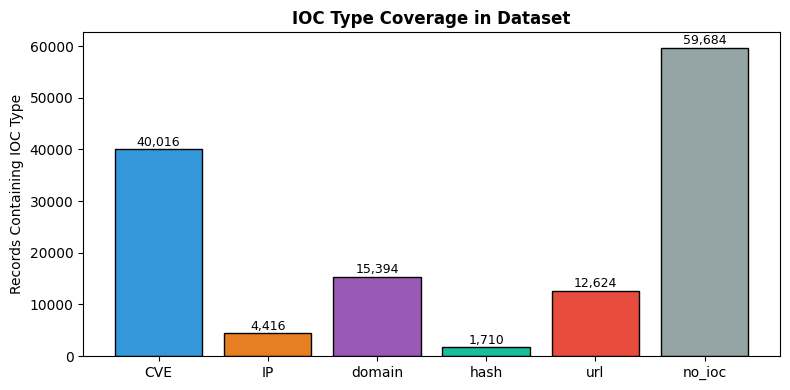

In [5]:
ioc_counts = {"has_CVE": 0, "has_IP": 0, "has_domain": 0,
              "has_hash": 0, "has_url": 0, "no_ioc": 0}

for r in records:
    msgs = r.get("messages", [])
    full_text = " ".join(m["content"] for m in msgs)
    has_any = False
    if re.search(r'CVE-\d{4}-\d+', full_text, re.IGNORECASE):
        ioc_counts["has_CVE"] += 1; has_any = True
    if re.search(r'\b\d{1,3}\[\.\]\d{1,3}\[\.\]\d{1,3}\[\.\]\d{1,3}\b', full_text):
        ioc_counts["has_IP"] += 1; has_any = True
    if re.search(r'\b[a-zA-Z0-9\-]+\[\.\][a-zA-Z]{2,10}\b', full_text):
        ioc_counts["has_domain"] += 1; has_any = True
    if re.search(r'\b[a-fA-F0-9]{32,64}\b', full_text):
        ioc_counts["has_hash"] += 1; has_any = True
    if re.search(r'hxxps?://', full_text):
        ioc_counts["has_url"] += 1; has_any = True
    if not has_any:
        ioc_counts["no_ioc"] += 1

for ioc_type, count in ioc_counts.items():
    print(f"  {ioc_type:<15} {count:>6} ({count/total*100:.1f}%)")

fig, ax = plt.subplots(figsize=(8, 4))
labels = [k.replace("has_", "") for k in list(ioc_counts.keys())]
values = list(ioc_counts.values())
colors = ['#3498db','#e67e22','#9b59b6','#1abc9c','#e74c3c','#95a5a6']
bars = ax.bar(labels, values, color=colors, edgecolor='black')
ax.set_ylabel("Records Containing IOC Type")
ax.set_title("IOC Type Coverage in Dataset", fontweight='bold')
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
            f'{val:,}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/ioc_coverage.png", dpi=150)
plt.show()


## 5. MITRE ATT&CK Technique Coverage

Counts how many distinct ATT&CK technique IDs (`Txxxx` and sub-techniques `Txxxx.NNN`) appear anywhere in the dataset. This is a proxy for how broad the model's red-team TTP vocabulary should be.

A wide spread across techniques is desirable — narrow coverage would mean the model can only reason about a handful of attack patterns.


In [6]:
all_techniques = []
for r in records:
    msgs = r.get("messages", [])
    full_text = " ".join(m["content"] for m in msgs)
    techs = re.findall(r'T\d{4}(?:\.\d{3})?', full_text)
    all_techniques.extend(techs)

tech_counter = collections.Counter(all_techniques)
print(f"  Unique techniques referenced : {len(tech_counter):,}")
print(f"  Total technique mentions     : {sum(tech_counter.values()):,}")
print(f"\n  Top 15 most referenced techniques:")
for tech, count in tech_counter.most_common(15):
    print(f"    {tech}  x{count}")


  Unique techniques referenced : 858
  Total technique mentions     : 68,723

  Top 15 most referenced techniques:
    T1078  x5287
    T1055  x4416
    T1021  x2231
    T1071  x1911
    T1059  x1749
    T1566  x1468
    T1027  x1431
    T1190  x1311
    T1203  x1264
    T1562  x1251
    T1068  x1113
    T1041  x1092
    T1083  x1082
    T1552  x966
    T1573  x925


## 6. Kill Chain Phase Coverage

Each record may touch multiple kill chain phases. This cell scans assistant responses for phase-specific keywords (`reconnaissance`, `lateral movement`, `c2`, `ransomware`, …) and counts records that touch each phase.

Imbalanced coverage is informative: a phase with very few records is one the model will be weak on. A healthy training set covers all phases reasonably, with somewhat heavier weighting on the phases where threat data is naturally richer (Initial Access, Execution, Impact).


  (Records can cover multiple phases)

  Reconnaissance             70129 (61.3%)  ██████████████████
  Initial Access             19356 (16.9%)  █████
  Privilege Escalation        7964 (7.0%)  ██
  Credential Access           7650 (6.7%)  ██
  Persistence                 7164 (6.3%)  █
  Command & Control           6846 (6.0%)  █
  Lateral Movement            5134 (4.5%)  █
  Execution                   4717 (4.1%)  █
  Exfiltration                4511 (3.9%)  █
  Impact                      1608 (1.4%)  


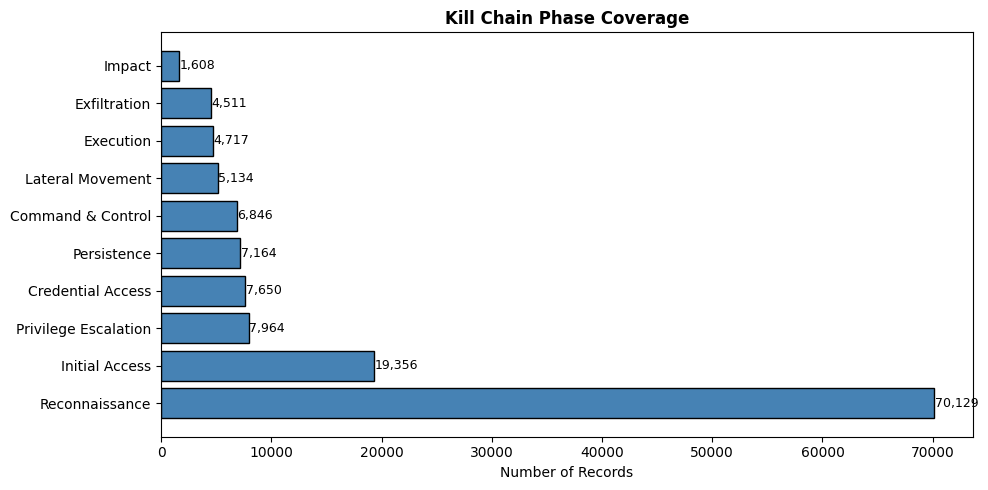

In [7]:
kill_chain_keywords = {
    "Reconnaissance":       ['reconnaissance', 'recon', 'scanning', 'enumeration', 'osint'],
    "Initial Access":       ['initial access', 'phishing', 'spear phishing', 'watering hole'],
    "Execution":            ['code execution', 'shellcode', 'macro', 'script execution'],
    "Persistence":          ['persistence', 'backdoor', 'rootkit', 'scheduled task'],
    "Privilege Escalation": ['privilege escalation', 'privesc', 'elevation of privilege'],
    "Credential Access":    ['credential', 'mimikatz', 'lsass', 'kerberoasting'],
    "Lateral Movement":     ['lateral movement', 'pass the hash', 'psexec', 'rdp'],
    "Command & Control":    ['command and control', 'c2', 'cobalt strike', 'beacon'],
    "Exfiltration":         ['exfiltration', 'data theft', 'exfiltrate'],
    "Impact":               ['ransomware', 'wiper', 'encrypt files', 'destruction'],
}

phase_counts = collections.defaultdict(int)
for r in records:
    msgs = r.get("messages", [])
    asst_text = next((m["content"].lower() for m in msgs if m["role"] == "assistant"), "")
    for phase, keywords in kill_chain_keywords.items():
        if any(kw in asst_text for kw in keywords):
            phase_counts[phase] += 1

print("  (Records can cover multiple phases)\n")
for phase, count in sorted(phase_counts.items(), key=lambda x: -x[1]):
    bar = "█" * int(count / total * 30)
    print(f"  {phase:<25} {count:>6} ({count/total*100:.1f}%)  {bar}")

fig, ax = plt.subplots(figsize=(10, 5))
phases = list(phase_counts.keys())
counts = [phase_counts[p] for p in phases]
sorted_pairs = sorted(zip(counts, phases), reverse=True)
counts, phases = zip(*sorted_pairs)
ax.barh(phases, counts, color='steelblue', edgecolor='black')
ax.set_xlabel("Number of Records")
ax.set_title("Kill Chain Phase Coverage", fontweight='bold')
for i, v in enumerate(counts):
    ax.text(v + 50, i, f'{v:,}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/kill_chain_coverage.png", dpi=150)
plt.show()


## 7. Summary

Quick-glance statistics for citation in reports and the README.


In [8]:
print(f"  Total training records        : {total:,}")
print(f"  Unique data sources           : {len(source_counts)}")
print(f"  Real vs synthetic ratio       : {real_count/total*100:.1f}% real")
print(f"  Avg text length (user msg)    : {statistics.mean(lengths):.0f} chars")
print(f"  Records with at least 1 IOC   : {total - ioc_counts['no_ioc']:,} ({(total-ioc_counts['no_ioc'])/total*100:.1f}%)")
print(f"  Unique ATT&CK techniques      : {len(tech_counter)}")
print(f"  Kill chain phases covered     : {len([p for p,c in phase_counts.items() if c > 0])}/10")
print(f"\n  All charts saved to: {OUT_DIR}/")


  Total training records        : 114,403
  Unique data sources           : 23
  Real vs synthetic ratio       : 81.8% real
  Avg text length (user msg)    : 507 chars
  Records with at least 1 IOC   : 54,719 (47.8%)
  Unique ATT&CK techniques      : 858
  Kill chain phases covered     : 10/10

  All charts saved to: /home/maximuz/osint-project/reports/eda/
